In [3]:
%cd "/scratch/network/ks2663/COLLAB/cos484-tokenizer-attack"

/scratch/network/ks2663/COLLAB/cos484-tokenizer-attack


In [10]:
from pathlib import Path
import json
from tqdm import tqdm
from collections import defaultdict
import os
import matplotlib.pyplot as plt
from utils import ensure_dir, read_predictions, read_merges_txt, mse, read_json, get_pair_to_byte_ratios, score_solution
from train_mixed_tokenizer import sample_from_unit_simplex
import seaborn as sns
import pandas as pd
import numpy as np
import string
import itertools

In [11]:
MIXTURE_TYPES = ['languages', 'code', 'domains']

In [12]:
from matplotlib import font_manager
import colorsys
import matplotlib.colors as mcolors

font_dir = ["../FONTS"]
for font in font_manager.findSystemFonts(font_dir):
    font_manager.fontManager.addfont(font)

plt.rcParams.update({
    "font.family": "Macho",
    "axes.linewidth": 1.5,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "legend.labelcolor": "#333333",
    "text.color": "#333333",
    "font.size": 14,
})

# Main Experiments (§4)

In [13]:
mses = {m: defaultdict(list) for m in MIXTURE_TYPES + ['random', 'uniform']}
dummy_codes = [''.join(tup) for tup in itertools.product(string.ascii_lowercase, string.ascii_lowercase)]

for n in [5, 10, 30, 112]:
    for mixture_type in MIXTURE_TYPES:
        experiment_dir = Path(f'experiments/mixed_{mixture_type}/n_{n}')
        if os.path.exists(experiment_dir):
            for test_id in tqdm(range(100), desc=f'{mixture_type}, n={n}'):
                solved = False
                for T in [29757, 29776, 29778, 29780]:
                    try:
                        s = score_solution(experiment_dir / str(test_id), f'solution6_pairs_{T}.json')
                        mses[mixture_type][n].append(s)
                        solved = True
                        break
                    except FileNotFoundError:
                        continue
                if not solved:
                    print(f'mixed_{mixture_type}/n_{n}/{test_id}')
    
    # calculate random accuracy
    for _ in tqdm(range(10**6), desc=f'random, n={n}'):
        true = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
        pred = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
        s = mse(true, pred)
        mses['random'][n].append(s)

    # calculate accuracy of uniform guess
    for _ in tqdm(range(10**6), desc=f'uniform, n={n}'):
        true = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
        pred = {l: 1/n for l in dummy_codes}
        s = mse(true, pred)
        mses['uniform'][n].append(s)

languages, n=5: 100%|██████████| 100/100 [00:00<00:00, 6684.90it/s]


mixed_languages/n_5/0
mixed_languages/n_5/1
mixed_languages/n_5/2
mixed_languages/n_5/3
mixed_languages/n_5/4
mixed_languages/n_5/5
mixed_languages/n_5/6
mixed_languages/n_5/7
mixed_languages/n_5/8
mixed_languages/n_5/9
mixed_languages/n_5/10
mixed_languages/n_5/11
mixed_languages/n_5/12
mixed_languages/n_5/13
mixed_languages/n_5/14
mixed_languages/n_5/15
mixed_languages/n_5/16
mixed_languages/n_5/17
mixed_languages/n_5/18
mixed_languages/n_5/19
mixed_languages/n_5/20
mixed_languages/n_5/21
mixed_languages/n_5/22
mixed_languages/n_5/23
mixed_languages/n_5/24
mixed_languages/n_5/25
mixed_languages/n_5/26
mixed_languages/n_5/27
mixed_languages/n_5/28
mixed_languages/n_5/29
mixed_languages/n_5/30
mixed_languages/n_5/31
mixed_languages/n_5/32
mixed_languages/n_5/33
mixed_languages/n_5/34
mixed_languages/n_5/35
mixed_languages/n_5/36
mixed_languages/n_5/37
mixed_languages/n_5/38
mixed_languages/n_5/39
mixed_languages/n_5/40
mixed_languages/n_5/41
mixed_languages/n_5/42
mixed_languages/n_5/4

code, n=5: 100%|██████████| 100/100 [00:00<00:00, 8791.43it/s]


mixed_code/n_5/0
mixed_code/n_5/1
mixed_code/n_5/2
mixed_code/n_5/3
mixed_code/n_5/4
mixed_code/n_5/5
mixed_code/n_5/6
mixed_code/n_5/7
mixed_code/n_5/8
mixed_code/n_5/9
mixed_code/n_5/10
mixed_code/n_5/11
mixed_code/n_5/12
mixed_code/n_5/13
mixed_code/n_5/14
mixed_code/n_5/15
mixed_code/n_5/16
mixed_code/n_5/17
mixed_code/n_5/18
mixed_code/n_5/19
mixed_code/n_5/20
mixed_code/n_5/21
mixed_code/n_5/22
mixed_code/n_5/23
mixed_code/n_5/24
mixed_code/n_5/25
mixed_code/n_5/26
mixed_code/n_5/27
mixed_code/n_5/28
mixed_code/n_5/29
mixed_code/n_5/30
mixed_code/n_5/31
mixed_code/n_5/32
mixed_code/n_5/33
mixed_code/n_5/34
mixed_code/n_5/35
mixed_code/n_5/36
mixed_code/n_5/37
mixed_code/n_5/38
mixed_code/n_5/39
mixed_code/n_5/40
mixed_code/n_5/41
mixed_code/n_5/42
mixed_code/n_5/43
mixed_code/n_5/44
mixed_code/n_5/45
mixed_code/n_5/46
mixed_code/n_5/47
mixed_code/n_5/48
mixed_code/n_5/49
mixed_code/n_5/50
mixed_code/n_5/51
mixed_code/n_5/52
mixed_code/n_5/53
mixed_code/n_5/54
mixed_code/n_5/55
mi

languages, n=10: 100%|██████████| 100/100 [00:00<00:00, 2675.54it/s]


...

languages, n=30: 100%|██████████| 100/100 [00:00<00:00, 7036.36it/s]


mixed_languages/n_30/0
mixed_languages/n_30/1
mixed_languages/n_30/2
mixed_languages/n_30/3
mixed_languages/n_30/4
mixed_languages/n_30/5
mixed_languages/n_30/6
mixed_languages/n_30/7
mixed_languages/n_30/8
mixed_languages/n_30/9
mixed_languages/n_30/10
mixed_languages/n_30/11
mixed_languages/n_30/12
mixed_languages/n_30/13
mixed_languages/n_30/14
mixed_languages/n_30/15
mixed_languages/n_30/16
mixed_languages/n_30/17
mixed_languages/n_30/18
mixed_languages/n_30/19
mixed_languages/n_30/20
mixed_languages/n_30/21
mixed_languages/n_30/22
mixed_languages/n_30/23
mixed_languages/n_30/24
mixed_languages/n_30/25
mixed_languages/n_30/26
mixed_languages/n_30/27
mixed_languages/n_30/28
mixed_languages/n_30/29
mixed_languages/n_30/30
mixed_languages/n_30/31
mixed_languages/n_30/32
mixed_languages/n_30/33
mixed_languages/n_30/34
mixed_languages/n_30/35
mixed_languages/n_30/36
mixed_languages/n_30/37
mixed_languages/n_30/38
mixed_languages/n_30/39
mixed_languages/n_30/40
mixed_languages/n_30/41
mi

code, n=30: 100%|██████████| 100/100 [00:00<00:00, 9811.24it/s]


mixed_code/n_30/0
mixed_code/n_30/1
mixed_code/n_30/2
mixed_code/n_30/3
mixed_code/n_30/4
mixed_code/n_30/5
mixed_code/n_30/6
mixed_code/n_30/7
mixed_code/n_30/8
mixed_code/n_30/9
mixed_code/n_30/10
mixed_code/n_30/11
mixed_code/n_30/12
mixed_code/n_30/13
mixed_code/n_30/14
mixed_code/n_30/15
mixed_code/n_30/16
mixed_code/n_30/17
mixed_code/n_30/18
mixed_code/n_30/19
mixed_code/n_30/20
mixed_code/n_30/21
mixed_code/n_30/22
mixed_code/n_30/23
mixed_code/n_30/24
mixed_code/n_30/25
mixed_code/n_30/26
mixed_code/n_30/27
mixed_code/n_30/28
mixed_code/n_30/29
mixed_code/n_30/30
mixed_code/n_30/31
mixed_code/n_30/32
mixed_code/n_30/33
mixed_code/n_30/34
mixed_code/n_30/35
mixed_code/n_30/36
mixed_code/n_30/37
mixed_code/n_30/38
mixed_code/n_30/39
mixed_code/n_30/40
mixed_code/n_30/41
mixed_code/n_30/42
mixed_code/n_30/43
mixed_code/n_30/44
mixed_code/n_30/45
mixed_code/n_30/46
mixed_code/n_30/47
mixed_code/n_30/48
mixed_code/n_30/49
mixed_code/n_30/50
mixed_code/n_30/51
mixed_code/n_30/52
mix

uniform, n=112: 100%|██████████| 1000000/1000000 [02:18<00:00, 7231.59it/s]


In [14]:
for mixture_type in MIXTURE_TYPES + ['random', 'uniform']:
    for n in [5, 10, 30, 112]:
        if n in mses[mixture_type]:
            l = [np.log10(s) for s in mses[mixture_type][n]]
            print(f'{mixture_type}, n={n}: {np.around(np.mean(l), 2)} +- {np.around(np.std(l), 2)}')

random, n=5: -1.39 +- 0.36
random, n=10: -1.84 +- 0.23
random, n=30: -2.7 +- 0.13
random, n=112: -3.82 +- 0.07
uniform, n=5: -1.67 +- 0.31
uniform, n=10: -2.14 +- 0.22
uniform, n=30: -3.01 +- 0.14
uniform, n=112: -4.12 +- 0.08


# Distribution shift analysis (§6.1)

In [15]:
r

1e06:   0%|          | 0/100 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'experiments/mixed_languages_shift/n_10/0/solution6_pairs_100_1e06.json'

In [16]:
D_col, T_col, score_col = [], [], []

for e, data in mses.items():
    for T, scores in data.items():
        for s in scores:
            D_col.append(10**e)
            T_col.append(T)
            score_col.append(s)

In [17]:
data = pd.DataFrame({'D': D_col, 'T': T_col, 'MSE': score_col})

/tmp/ipykernel_2496452/2177627403.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=data, x='D', y='MSE', hue='T', palette=sns.cubehelix_palette(start=.5, rot=-.75, n_colors=6))
/tmp/ipykernel_2496452/2177627403.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='# merges T', loc='upper left', fontsize=12, title_fontsize=12, handlelength=1)
findfont: Font family 'Macho' not found.
findfont: Font family ['Macho'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font famil

FileNotFoundError: [Errno 2] No such file or directory: 'plots/shift_bytes_data_scaling.pdf'

findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.


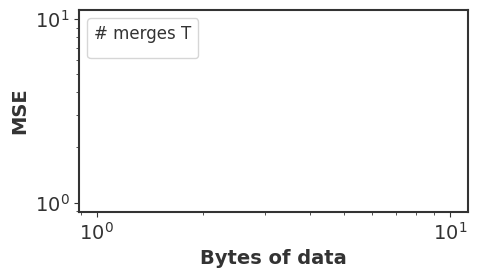

In [18]:
fig, ax = plt.subplots(figsize=(5,3))
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel('Bytes of data', fontweight='semibold')
ax.set_ylabel('MSE', fontweight='semibold')
sns.lineplot(data=data, x='D', y='MSE', hue='T', palette=sns.cubehelix_palette(start=.5, rot=-.75, n_colors=6))
ax.legend(title='# merges T', loc='upper left', fontsize=12, title_fontsize=12, handlelength=1)
plt.tight_layout()
plt.savefig('plots/shift_bytes_data_scaling.pdf', dpi=300)

/tmp/ipykernel_2496452/257631357.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=data, x='T', y='MSE', hue='e', palette=sns.cubehelix_palette(n_colors=5))
/tmp/ipykernel_2496452/257631357.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Bytes of data', loc='lower left', fontsize=12, title_fontsize=12, handlelength=1)
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family ['Macho'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found

FileNotFoundError: [Errno 2] No such file or directory: 'plots/shift_num_merges_scaling.pdf'

findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.


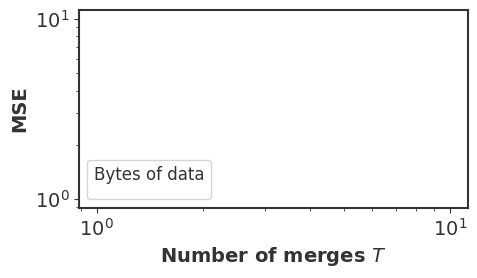

In [19]:
fig, ax = plt.subplots(figsize=(5,3))
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel('Number of merges $T$', fontweight='semibold')
ax.set_ylabel('MSE', fontweight='semibold')
data['e'] = [f'10^{int(np.log10(d))}' for d in data['D']]
sns.lineplot(data=data, x='T', y='MSE', hue='e', palette=sns.cubehelix_palette(n_colors=5))
ax.legend(title='Bytes of data', loc='lower left', fontsize=12, title_fontsize=12, handlelength=1)
plt.tight_layout()
plt.savefig('plots/shift_num_merges_scaling.pdf', dpi=300)

# Unaccounted-for languages analysis (§6.2)

In [ ]:
experiment_dir = Path('experiments/mixed_languages/n_112')

In [20]:
mses = []
for test_id in tqdm(range(100)):
    test_id = str(test_id)
    for n_omit in [1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        solution_file = f'solution6_pairs_29778_langlist_omit{n_omit}.json'
        try:
            preds = read_predictions(experiment_dir / test_id / solution_file)
        except FileNotFoundError:
            continue
        
        meta = read_json(experiment_dir / test_id / 'meta.json')
        truth = {k: v / sum(meta['byte_count'].values()) for k, v in meta['byte_count'].items()}

        included_langs = [l.rstrip() for l in open(experiment_dir / test_id / f'langlist_omit{n_omit}.txt').readlines()]
        prob_omitted = sum([v for k, v in truth.items() if k not in included_langs])
        renorm_truth = {k: v for k, v in truth.items() if k in included_langs}
        renorm_truth = {k: v / sum(renorm_truth.values()) for k, v in renorm_truth.items()}
        assert len(renorm_truth) == 112 - n_omit
        
        pair_to_byte_ratio = get_pair_to_byte_ratios(experiment_dir / test_id)
        
        converted_preds = {}
        for lang, p in preds.items():
            converted_preds[lang] = p * pair_to_byte_ratio[lang]
        converted_preds = {k: v / sum(converted_preds.values()) for k, v in converted_preds.items()}
        
        s = mse(renorm_truth, converted_preds)
        
        mses.append({
            'test_id': int(test_id),
            'n_omit': n_omit,
            'prob_omitted': prob_omitted,
            'mse': s
        })

100%|██████████| 100/100 [00:00<00:00, 5807.92it/s]


ValueError: min() iterable argument is empty

findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.


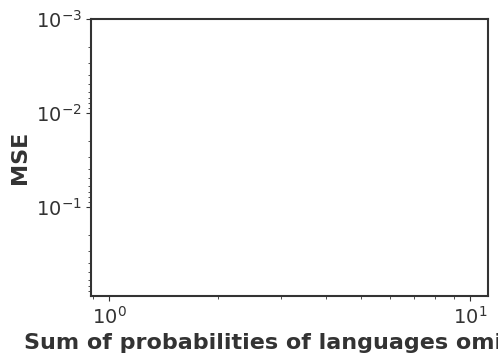

In [21]:
x = [ex['prob_omitted'] for ex in mses]
y = [ex['mse'] for ex in mses]
fig, ax = plt.subplots(figsize=(6.4*4/5,4.8*3/4))
plt.xscale('log')
plt.yscale('log')
sns.scatterplot(x=x, y=y, alpha=0.8)
ax.set_xlabel('Sum of probabilities of languages omitted', fontsize=16, fontweight='semibold')
ax.set_ylabel('MSE', fontsize=16, fontweight='semibold')
ax.set_ylim(top=10**-3)

# Add horizontal line at log_10(-3.82)
log_rand_guess = -3.82
ax.axhline(y=10**log_rand_guess, color=sns.color_palette()[-3], linestyle='--', label='Random Guessing')

# Label for the horizontal line
ax.text(min(x), 10**log_rand_guess, 'Random Guess', fontsize=12, verticalalignment='bottom')

plt.tight_layout()
plt.savefig('plots/missing_lang.png', dpi=300)
plt.savefig('plots/missing_lang.pdf', dpi=300)